# Assignment 2: ML Experiment Tracking using MLflow

## Objective

To track and manage machine learning experiments using MLflow.

In this assignment, the Iris dataset is used to train a machine learning classification model. Multiple experiments will be performed by changing model hyperparameters, and MLflow will be used to record the parameters, evaluation metrics, and trained models for each experiment.

### Key Tasks

- Load and preprocess the Iris dataset.
- Split the dataset into training and testing sets.
- Train a machine learning model with different hyperparameters.
- Track experiments using MLflow.
- Log model parameters and performance metrics.
- Store trained models as MLflow artifacts.
- Compare different experiment runs.
- Identify the best-performing model.

### Tools and Libraries

- Python
- Pandas
- Scikit-learn
- MLflow
- Matplotlib

In [1]:
print("Assignment 2: ML Experiment Tracking using MLflow")
print("Dataset: Iris Dataset")

Assignment 2: ML Experiment Tracking using MLflow
Dataset: Iris Dataset


## 1. Import Required Libraries

The following Python libraries are required for this assignment:

- **Pandas** – for data manipulation and analysis.
- **NumPy** – for numerical operations.
- **Matplotlib** – for data visualization.
- **Scikit-learn** – for dataset loading, preprocessing, model training, and evaluation.
- **MLflow** – for tracking machine learning experiments, parameters, metrics, and models.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

print("All libraries imported successfully.")
print("MLflow version:", mlflow.__version__)

All libraries imported successfully.
MLflow version: 3.15.1


## 2. Load the Dataset

The **Iris dataset** is a commonly used dataset for machine learning classification problems.

It contains measurements of iris flowers belonging to three different species:

- Setosa
- Versicolor
- Virginica

The dataset contains four input features:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

The target variable represents the species of the flower.

In [3]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame
df = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

# Add target column
df["target"] = iris.target

# Display the first five records
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Dataset Exploration

Before training the machine learning model, the dataset is examined to understand its structure and basic statistical properties.

The following information will be checked:

- Number of rows and columns
- Data types of the features
- Presence of missing values
- Statistical summary of numerical features

In [4]:
# Display dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (150, 5)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 4. Prepare Features and Target Variable

The dataset is divided into:

- **Features (X):** The four measurements of the iris flower.
- **Target (y):** The flower species represented by values 0, 1, and 2.

The target column is separated from the input features so that the machine learning model can learn the relationship between the flower measurements and its species.

In [5]:
# Separate features and target variable
X = df.drop("target", axis=1)
print("Features (X):")
display(X.head())
print("\nFeature Shape:", X.shape)

Features (X):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Feature Shape: (150, 4)


In [6]:
y = df["target"]
print("Target (y):")
display(y.head())
print("Target Shape:", y.shape)

Target (y):


0    0
1    0
2    0
3    0
4    0
Name: target, dtype: int64

Target Shape: (150,)


## 5. Split the Dataset into Training and Testing Sets

The dataset is divided into two subsets:

- **Training set:** Used to train the machine learning model.
- **Testing set:** Used to evaluate the model on unseen data.

An 80:20 split is used, where 80% of the data is used for training and 20% is used for testing.

The `stratify` parameter ensures that the proportion of each flower species remains approximately the same in both the training and testing sets.

In [7]:
# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting target distribution:")
print(y_test.value_counts().sort_index())

Training set shape: (120, 4)
Testing set shape: (30, 4)

Training target distribution:
target
0    40
1    40
2    40
Name: count, dtype: int64

Testing target distribution:
target
0    10
1    10
2    10
Name: count, dtype: int64


## 6. Feature Scaling

Feature scaling is performed to bring all input features to a similar scale.

The `StandardScaler` standardizes each feature by removing its mean and scaling it to unit variance.

The scaler is fitted only on the training data to avoid data leakage. The same transformation is then applied to the testing data.

This preprocessing step is useful for models such as Logistic Regression because it can improve optimization and model stability.

In [8]:
# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform the testing data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:")
display(pd.DataFrame(X_train_scaled, columns=X.columns).head())

print("\nTesting data shape:", X_test_scaled.shape)

Training data after scaling:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-1.721568,-0.332101,-1.345722,-1.323276
1,-1.124492,-1.227655,0.414505,0.651763
2,1.144395,-0.555990,0.584850,0.256755
3,-1.124492,0.115676,-1.288941,-1.454945
4,-0.408002,-1.227655,0.130598,0.125086



Testing data shape: (30, 4)


## 7. Set Up MLflow Experiment Tracking

MLflow is used to track the machine learning experiments performed in this assignment.

An MLflow experiment provides a logical grouping for related runs. Each run can record:

- Model parameters
- Evaluation metrics
- Trained model artifacts
- Additional experiment information

The experiment is named `Iris_Classification_Experiments`. If the experiment does not already exist, MLflow will create it.

In [9]:
# Set the MLflow experiment
experiment_name = "Iris_Classification_Experiments"

mlflow.set_experiment(experiment_name)

print(f"MLflow experiment set to: {experiment_name}")

2026/08/15 15:19:22 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/08/15 15:19:22 INFO mlflow.store.db.utils: Updating database tables
2026/08/15 15:19:23 INFO mlflow.tracking.fluent: Experiment with name 'Iris_Classification_Experiments' does not exist. Creating a new experiment.


MLflow experiment set to: Iris_Classification_Experiments


## 8. Baseline Experiment – Logistic Regression

A baseline Logistic Regression model is trained using the scaled training data.

For this first experiment, the default model configuration is used. MLflow records the experiment as a run and logs:

- Model type
- Hyperparameters
- Test accuracy
- Classification report
- Trained model

This baseline experiment will serve as a reference for comparing the performance of subsequent experiments.

In [10]:
# Start the baseline MLflow run
with mlflow.start_run(run_name="Baseline_Logistic_Regression"):

    # Create the baseline model
    model = LogisticRegression(
        random_state=42,
        max_iter=200
    )

    # Train the model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred = model.predict(X_test_scaled)

    # Calculate accuracy
    accuracy = accuracy_score(y_test, y_pred)

    # Log parameters
    mlflow.log_param("model", "Logistic Regression")
    mlflow.log_param("random_state", 42)
    mlflow.log_param("max_iter", 200)

    # Log metric
    mlflow.log_metric("accuracy", accuracy)

    # Log the trained model
    mlflow.sklearn.log_model(
        model,
        name="logistic_regression_model"
    )

    # Display results
    print("Baseline Logistic Regression")
    print("-" * 35)
    print(f"Test Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

Baseline Logistic Regression
-----------------------------------
Test Accuracy: 0.9333

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       0.90      0.90      0.90        10
           2       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 9. Experiment 1 – Effect of Regularization Strength

The `C` parameter in Logistic Regression controls the strength of regularization.

- A **smaller C** applies stronger regularization.
- A **larger C** applies weaker regularization.

To study its effect on model performance, the model is trained using different values of `C`.

Each configuration is recorded as a separate MLflow run so that the parameters and results can be compared later.

The values used are:

- C = 0.1
- C = 1.0
- C = 10.0

In [11]:
# Experiment with different regularization strengths
c_values = [0.1, 1.0, 10.0]

for c in c_values:

    # Create a valid MLflow model name
    c_name = str(c).replace(".", "_")

    with mlflow.start_run(run_name=f"Logistic_Regression_C_{c}"):

        # Create model with different C values
        model = LogisticRegression(
            C=c,
            random_state=42,
            max_iter=200
        )

        # Train the model
        model.fit(X_train_scaled, y_train)

        # Make predictions
        y_pred = model.predict(X_test_scaled)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Log parameters
        mlflow.log_param("model", "Logistic Regression")
        mlflow.log_param("C", c)
        mlflow.log_param("random_state", 42)
        mlflow.log_param("max_iter", 200)

        # Log metric
        mlflow.log_metric("accuracy", accuracy)

        # Log the trained model
        mlflow.sklearn.log_model(
            model,
            name=f"logistic_regression_C_{c_name}"
        )

        print(f"C = {c:<4} | Test Accuracy = {accuracy:.4f}")

C = 0.1  | Test Accuracy = 0.8667
C = 1.0  | Test Accuracy = 0.9333
C = 10.0 | Test Accuracy = 1.0000


## 10. Experiment 2 – Effect of Maximum Iterations

The `max_iter` parameter specifies the maximum number of iterations allowed for the Logistic Regression optimization process.

Different values of `max_iter` are tested while keeping the other model parameters constant.

The values used are:

- max_iter = 50
- max_iter = 100
- max_iter = 200

Each configuration is recorded as a separate MLflow run.

This experiment helps demonstrate how model configuration changes can be tracked and compared using MLflow.

In [12]:
# Experiment with different maximum iteration values
max_iter_values = [50, 100, 200]

for max_iter in max_iter_values:

    with mlflow.start_run(run_name=f"Logistic_Regression_Iter_{max_iter}"):

        # Create the model
        model = LogisticRegression(
            C=1.0,
            random_state=42,
            max_iter=max_iter
        )

        # Train the model
        model.fit(X_train_scaled, y_train)

        # Make predictions
        y_pred = model.predict(X_test_scaled)

        # Calculate accuracy
        accuracy = accuracy_score(y_test, y_pred)

        # Log parameters
        mlflow.log_param("model", "Logistic Regression")
        mlflow.log_param("C", 1.0)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("random_state", 42)

        # Log metric
        mlflow.log_metric("accuracy", accuracy)

        # Log the trained model
        mlflow.sklearn.log_model(
            model,
            name=f"logistic_regression_iter_{max_iter}"
        )

        print(f"max_iter = {max_iter:<3} | Test Accuracy = {accuracy:.4f}")

max_iter = 50  | Test Accuracy = 0.9333
max_iter = 100 | Test Accuracy = 0.9333
max_iter = 200 | Test Accuracy = 0.9333


## 11. Retrieve and Compare MLflow Runs

MLflow stores information about every experiment run, including the parameters and metrics that were logged during model training.

The experiment runs are retrieved using the MLflow tracking API and displayed in a DataFrame.

This allows the different model configurations and their corresponding test accuracies to be compared in a single table.

In [13]:
# Get the MLflow experiment
experiment = mlflow.get_experiment_by_name(experiment_name)

# Retrieve successful runs only
runs = mlflow.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="attributes.status = 'FINISHED'"
)

# Select relevant columns
comparison = runs[
    [
        "run_id",
        "tags.mlflow.runName",
        "params.model",
        "params.C",
        "params.max_iter",
        "metrics.accuracy"
    ]
].copy()

# Rename columns
comparison.columns = [
    "Run ID",
    "Run Name",
    "Model",
    "C",
    "Max Iterations",
    "Accuracy"
]

# Sort by accuracy
comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

display(comparison)

,Run ID,Run Name,Model,C,Max Iterations,Accuracy
0,357b6dbc772a44e0ae9834bbb899f1c9,Logistic_Regression_C_10.0,Logistic Regression,10.0,200,1.000000
1,9ae2126eaccb4acaaf8371de232d686f,Logistic_Regression_Iter_100,Logistic Regression,1.0,100,0.933333
2,9e5ccdb180804bfdb4c9e21829649e49,Logistic_Regression_Iter_200,Logistic Regression,1.0,200,0.933333
3,035d15f253c94bd3b65270e6beb2e124,Logistic_Regression_Iter_50,Logistic Regression,1.0,50,0.933333
4,1ca2279ca82c4f6f9659d5de3ab39087,Logistic_Regression_C_1.0,Logistic Regression,1.0,200,0.933333
5,343c712fba484204a11eed1bf9f01ab8,Baseline_Logistic_Regression,Logistic Regression,None,200,0.933333
6,6cf39086bc5447dd804bfcb7d3fa54ce,Logistic_Regression_C_0.1,Logistic Regression,0.1,200,0.866667


## 12. Visualization of Experiment Results

The accuracy of the successful MLflow runs is visualized using a bar chart.

This visualization makes it easier to compare the performance of the different experiments and identify the best-performing configuration.

The experiment with the highest test accuracy is considered the best-performing run.

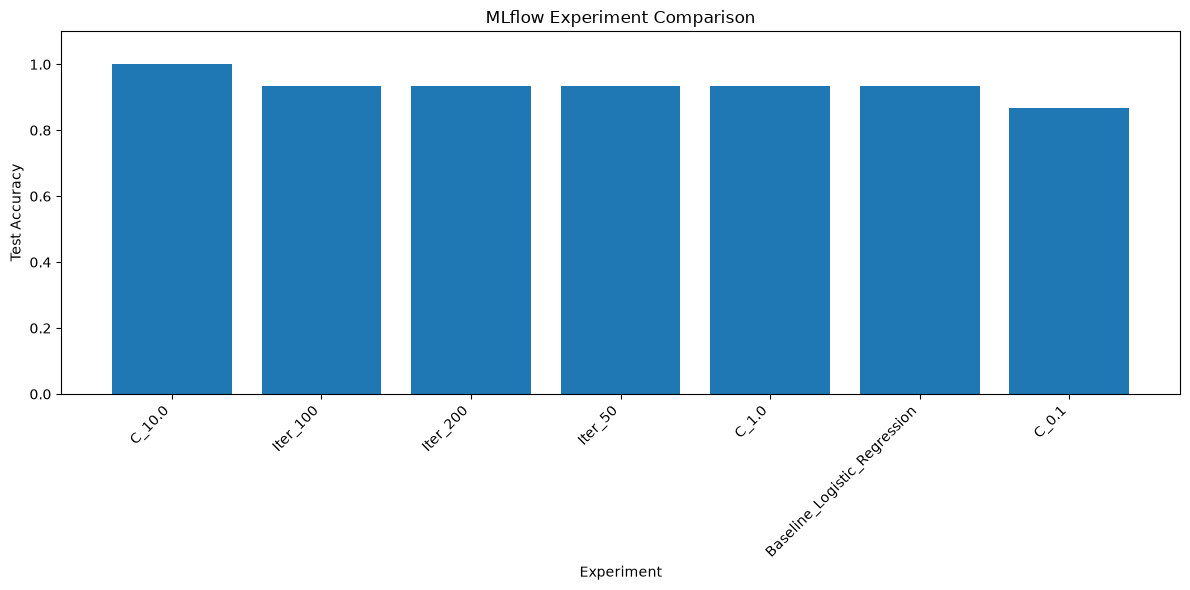

In [14]:
# Create labels for the experiment runs
comparison["Experiment"] = comparison["Run Name"].str.replace(
    "Logistic_Regression_", "",
    regex=False
)

# Plot experiment accuracies
plt.figure(figsize=(12, 6))

plt.bar(
    comparison["Experiment"],
    comparison["Accuracy"]
)

plt.xlabel("Experiment")
plt.ylabel("Test Accuracy")
plt.title("MLflow Experiment Comparison")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

## 13. Identify the Best-Performing Experiment

The best experiment is identified based on the highest test accuracy recorded in MLflow.

The run with the maximum accuracy is selected as the final best-performing experiment.

Its run name, hyperparameters, and accuracy are displayed for further analysis.

In [15]:
# Identify the best-performing experiment
best_run = comparison.loc[comparison["Accuracy"].idxmax()]

print("Best-Performing Experiment")
print("-" * 35)
print(f"Run Name       : {best_run['Run Name']}")
print(f"Model          : {best_run['Model']}")
print(f"C              : {best_run['C']}")
print(f"Max Iterations : {best_run['Max Iterations']}")
print(f"Test Accuracy  : {best_run['Accuracy']:.4f}")

Best-Performing Experiment
-----------------------------------
Run Name       : Logistic_Regression_C_10.0
Model          : Logistic Regression
C              : 10.0
Max Iterations : 200
Test Accuracy  : 1.0000


## 14. Final Evaluation of the Best Model

The best-performing experiment identified from the MLflow runs is used to train the final Logistic Regression model.

The model is evaluated on the unseen testing dataset using:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report

This provides a detailed evaluation of the final selected model.

In [16]:
# Get the best C value
best_c = float(best_run["C"])

# Train the final model using the best hyperparameters
final_model = LogisticRegression(
    C=best_c,
    random_state=42,
    max_iter=200
)

final_model.fit(X_train_scaled, y_train)

# Make predictions
final_predictions = final_model.predict(X_test_scaled)

# Calculate final accuracy
final_accuracy = accuracy_score(
    y_test,
    final_predictions
)

print("Final Model Evaluation")
print("-" * 35)
print(f"Best C Value: {best_c}")
print(f"Test Accuracy: {final_accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    final_predictions,
    target_names=iris.target_names
))

Final Model Evaluation
-----------------------------------
Best C Value: 10.0
Test Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



## 15. View Experiments using MLflow UI

MLflow provides a web-based user interface that allows us to inspect and compare experiment runs.

The MLflow UI displays:

- Experiment names
- Run names
- Parameters
- Metrics
- Model artifacts
- Run status

The UI will be launched locally and can be opened in a web browser to visually inspect the tracked experiments.

In [17]:
import subprocess
import sys

# Stop the previous MLflow process if it is running
try:
    mlflow_process.terminate()
except:
    pass

# Exact MLflow database used by the notebook
tracking_uri = (
    "sqlite:///D:/College/3rd_Year/MLOPS/"
    "Assignment-2-MLFlow/notebooks/mlflow.db"
)

print("Starting MLflow UI...")
print("Tracking database:")
print(tracking_uri)

# Start MLflow server
mlflow_process = subprocess.Popen(
    [
        sys.executable,
        "-m",
        "mlflow",
        "server",
        "--backend-store-uri",
        tracking_uri,
        "--host",
        "127.0.0.1",
        "--port",
        "5000"
    ]
)

print("\nMLflow server started.")
print("Open: http://127.0.0.1:5000")

Starting MLflow UI...
Tracking database:
sqlite:///D:/College/3rd_Year/MLOPS/Assignment-2-MLFlow/notebooks/mlflow.db

MLflow server started.
Open: http://127.0.0.1:5000


## 16. Conclusion

In this assignment, MLflow was used to track Logistic Regression experiments on the Iris dataset.

Different values of `C` and `max_iter` were tested and their parameters and accuracy were recorded using MLflow.

The best result was obtained with `C = 10.0`, which achieved **100% test accuracy**.

The MLflow UI was also used to view and compare the experiment runs.